In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

LEADERBOARD_PATH = "UI/tables/leaderboards_by_task.xlsx"
USE_COL = "Avg_Position"

SHEET_MAP = {
    "CLASSIFICATION": "OVERALL_CLASSIFICATION",
    "REGRESSION": "OVERALL_REGRESSION",
    "SURVIVAL": "OVERALL_SURVIVAL",
}

TASK_LABELS_RU = {
    "CLASSIFICATION": "классификации",
    "REGRESSION": "регрессии",
    "SURVIVAL": "выживаемости",
}

CLASSIF_MODELS = [
    "LogisticRegression",
    "KNeighborsClassifier",
    "DecisionTreeClassifier",
    "RandomForestClassifier",
    "GradientBoostingClassifier",
    "SVC",
]

REGR_MODELS = [
    "ElasticNet",
    "DecisionTreeRegressor",
    "RandomForestRegressor",
    "GradientBoostingRegressor",
    "SVR",
    "KNeighborsRegressor",
]

SURV_MODELS = [
    "KaplanMeierFitter",
    "CoxPHSurvivalAnalysis",
    "RandomSurvivalForest",
    "SurvivalTree",
    "GradientBoostingSurvivalAnalysis",
    "CRAID",
    "ParallelBootstrapCRAID",
]

SHORT_MODEL_NAMES = {
    "LogisticRegression": "LR",
    "KNeighborsClassifier": "KNN",
    "DecisionTreeClassifier": "DT",
    "RandomForestClassifier": "RF",
    "GradientBoostingClassifier": "GB",
    "DecisionTreeRegressor": "DT-R",
    "RandomForestRegressor": "RF-R",
    "GradientBoostingRegressor": "GB-R",
    "KNeighborsRegressor": "KNN-R",
    "KaplanMeierFitter": "KMF",
    "CoxPHSurvivalAnalysis": "CoxPH",
    "RandomSurvivalForest": "RSF",
    "SurvivalTree": "ST",
    "GradientBoostingSurvivalAnalysis": "GBSA",
    "ParallelBootstrapCRAID": "PB-CRAID",
}

PIECEWISE_PATTERN = re.compile(
    r"^(Piecewise(?:CensorAware)?ClassifWrapSA)\(([^,]+),\s*times=(\d+)\)$"
)

PIECEWISE_GROUPS = {
    "PiecewiseClassifWrapSA": "piecewise",
    "PiecewiseCensorAwareClassifWrapSA": "piecewise_censor_aware",
}

METHOD_STYLES = {
    "classification": {"label": "Классификация", "color": "tab:blue"},
    "regression": {"label": "Регрессия", "color": "tab:orange"},
    "survival": {"label": "Выживаемость", "color": "tab:green"},
    "piecewise": {"label": "PiecewiseClassifWrapSA", "color": "#ef4444"},
    "piecewise_censor_aware": {"label": "PiecewiseCensorAwareClassifWrapSA", "color": "#facc15"},
    "other": {"label": "Other", "color": "tab:gray"},
}

TIME_MARKERS = {
    4: "D",
    8: "P",
    16: "X",
    32: "*",
}

TIME_SIZES = {
    4: 125,
    8: 145,
    16: 165,
    32: 220,
}

TIME_LABELS = {
    4: "times=4",
    8: "times=8",
    16: "times=16",
    32: "times=32",
}

SELECTED_PIECEWISE_TIMES = {16}


def parse_piecewise_method(method):
    match = PIECEWISE_PATTERN.match(str(method))
    if not match:
        return None

    family_name, base_model, times = match.groups()
    group = PIECEWISE_GROUPS[family_name]
    times = int(times)

    return {
        "group": group,
        "family_name": family_name,
        "family_label": METHOD_STYLES[group]["label"],
        "base_model": base_model,
        "base_model_short": SHORT_MODEL_NAMES.get(base_model, base_model),
        "times": times,
        "plot_label": f"{base_model} t={times}",
    }


def method_metadata(method):
    piecewise = parse_piecewise_method(method)
    if piecewise is not None:
        return piecewise

    if method in CLASSIF_MODELS:
        group = "classification"
    elif method in REGR_MODELS:
        group = "regression"
    elif method in SURV_MODELS:
        group = "survival"
    else:
        group = "other"

    return {
        "group": group,
        "family_name": "",
        "family_label": METHOD_STYLES[group]["label"],
        "base_model": method,
        "base_model_short": SHORT_MODEL_NAMES.get(method, method),
        "times": None,
        "plot_label": method,
    }


def style_for_method(method):
    meta = method_metadata(method)
    style = METHOD_STYLES[meta["group"]].copy()

    if meta["times"] is None:
        style.update({
            "marker": "o",
            "size": 90,
            "edgecolor": style["color"],
            "linewidth": 0,
        })
    else:
        style.update({
            "marker": TIME_MARKERS.get(meta["times"], "^"),
            "size": TIME_SIZES.get(meta["times"], 150),
            "edgecolor": "black",
            "linewidth": 0.85,
        })

    return style


def build_legend_elements(cmp):
    legend = []
    present_groups = list(dict.fromkeys(cmp["group"].tolist()))

    for group_name in ["classification", "regression", "survival", "piecewise", "piecewise_censor_aware", "other"]:
        if group_name not in present_groups:
            continue
        style = METHOD_STYLES[group_name]
        legend.append(
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label=style["label"],
                markerfacecolor=style["color"],
                markeredgecolor=style["color"],
                markersize=10,
            )
        )

    present_times = sorted({int(value) for value in cmp["times"].dropna().tolist()})
    for times in present_times:
        legend.append(
            Line2D(
                [0],
                [0],
                marker=TIME_MARKERS.get(times, "^"),
                color="black",
                label=TIME_LABELS.get(times, f"times={times}"),
                markerfacecolor="white",
                markeredgecolor="black",
                linestyle="None",
                markersize=10,
            )
        )

    legend.append(Line2D([0], [0], linestyle="--", color="gray", label="x = y"))
    return legend


def render_task_comparison(task_x, task_y, use_col=USE_COL):
    x_col = f"{task_x}_{use_col}"
    y_col = f"{task_y}_{use_col}"

    df_x = pd.read_excel(LEADERBOARD_PATH, sheet_name=SHEET_MAP[task_x])
    df_y = pd.read_excel(LEADERBOARD_PATH, sheet_name=SHEET_MAP[task_y])

    df_x = df_x[["Method", use_col]].rename(columns={use_col: x_col})
    df_y = df_y[["Method", use_col]].rename(columns={use_col: y_col})

    cmp = df_x.merge(df_y, on="Method", how="inner")
    meta = cmp["Method"].apply(method_metadata).apply(pd.Series)
    cmp = pd.concat([cmp, meta], axis=1)
    cmp = cmp[cmp["times"].isna() | cmp["times"].isin(SELECTED_PIECEWISE_TIMES)].copy()
    cmp["delta"] = cmp[x_col] - cmp[y_col]
    cmp["abs_delta"] = cmp["delta"].abs()
    cmp = cmp.sort_values([x_col, y_col, "group", "times", "Method"], na_position="last").reset_index(drop=True)

    display(cmp)

    rank_table = cmp[[
        "Method",
        "plot_label",
        "family_label",
        "base_model",
        "times",
        x_col,
        y_col,
        "delta",
        "abs_delta",
    ]].copy()
    display(rank_table)

    plt.figure(figsize=(13, 10))

    for _, row in cmp.iterrows():
        style = style_for_method(row["Method"])
        plt.scatter(
            row[x_col],
            row[y_col],
            color=style["color"],
            marker=style["marker"],
            s=style["size"],
            alpha=0.9,
            edgecolors=style["edgecolor"],
            linewidths=style["linewidth"],
        )
        plt.annotate(
            row["plot_label"],
            (row[x_col], row[y_col]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=9,
            alpha=0.92,
        )

    xy_min = 1
    xy_max = max(cmp[x_col].max(), cmp[y_col].max())
    plt.plot([xy_min, xy_max], [xy_min, xy_max], "--", color="gray", alpha=0.6)
    plt.xlim(left=xy_min)
    plt.ylim(bottom=xy_min)
    plt.legend(handles=build_legend_elements(cmp), loc="best")

    plt.xlabel(f"Средняя позиция по задаче {TASK_LABELS_RU[task_x]}")
    plt.ylabel(f"Средняя позиция по задаче {TASK_LABELS_RU[task_y]}")
    plt.grid(alpha=0.3)
    plt.show()

    return cmp, rank_table


,Method,CLASSIFICATION_Avg_Position,SURVIVAL_Avg_Position,group,family_name,family_label,base_model,base_model_short,times,plot_label,delta,abs_delta
0,RandomForestClassifier,2.000000,13.571429,classification,,Классификация,RandomForestClassifier,RF,None,RandomForestClassifier,-11.571429,11.571429
1,GradientBoostingClassifier,2.142857,13.428571,classification,,Классификация,GradientBoostingClassifier,GB,None,GradientBoostingClassifier,-11.285714,11.285714
2,LogisticRegression,4.714286,13.571429,classification,,Классификация,LogisticRegression,LR,None,LogisticRegression,-8.857143,8.857143
3,GradientBoostingSurvivalAnalysis,4.857143,3.285714,survival,,Выживаемость,GradientBoostingSurvivalAnalysis,GBSA,None,GradientBoostingSurvivalAnalysis,1.571429,1.571429
4,SVC,5.571429,14.714286,classification,,Классификация,SVC,SVC,None,SVC,-9.142857,9.142857
5,RandomSurvivalForest,6.428571,5.714286,survival,,Выживаемость,RandomSurvivalForest,RSF,None,RandomSurvivalForest,0.714286,0.714286
6,ParallelBootstrapCRAID,7.285714,1.285714,survival,,Выживаемость,ParallelBootstrapCRAID,PB-CRAID,None,ParallelBootstrapCRAID,6.000000,6.000000
7,CoxPHSurvivalAnalysis,8.428571,6.428571,survival,,Выживаемость,CoxPHSurvivalAnalysis,CoxPH,None,CoxPHSurvivalAnalysis,2.000000,2.000000
8,CRAID,9.714286,3.000000,survival,,Выживаемость,CRAID,CRAID,None,CRAID,6.714286,6.714286
9,ElasticNet,12.000000,8.142857,regression,,Регрессия,ElasticNet,ElasticNet,None,ElasticNet,3.857143,3.857143


,Method,plot_label,family_label,base_model,times,CLASSIFICATION_Avg_Position,SURVIVAL_Avg_Position,delta,abs_delta
0,RandomForestClassifier,RandomForestClassifier,Классификация,RandomForestClassifier,None,2.000000,13.571429,-11.571429,11.571429
1,GradientBoostingClassifier,GradientBoostingClassifier,Классификация,GradientBoostingClassifier,None,2.142857,13.428571,-11.285714,11.285714
2,LogisticRegression,LogisticRegression,Классификация,LogisticRegression,None,4.714286,13.571429,-8.857143,8.857143
3,GradientBoostingSurvivalAnalysis,GradientBoostingSurvivalAnalysis,Выживаемость,GradientBoostingSurvivalAnalysis,None,4.857143,3.285714,1.571429,1.571429
4,SVC,SVC,Классификация,SVC,None,5.571429,14.714286,-9.142857,9.142857
5,RandomSurvivalForest,RandomSurvivalForest,Выживаемость,RandomSurvivalForest,None,6.428571,5.714286,0.714286,0.714286
6,ParallelBootstrapCRAID,ParallelBootstrapCRAID,Выживаемость,ParallelBootstrapCRAID,None,7.285714,1.285714,6.000000,6.000000
7,CoxPHSurvivalAnalysis,CoxPHSurvivalAnalysis,Выживаемость,CoxPHSurvivalAnalysis,None,8.428571,6.428571,2.000000,2.000000
8,CRAID,CRAID,Выживаемость,CRAID,None,9.714286,3.000000,6.714286,6.714286
9,ElasticNet,ElasticNet,Регрессия,ElasticNet,None,12.000000,8.142857,3.857143,3.857143


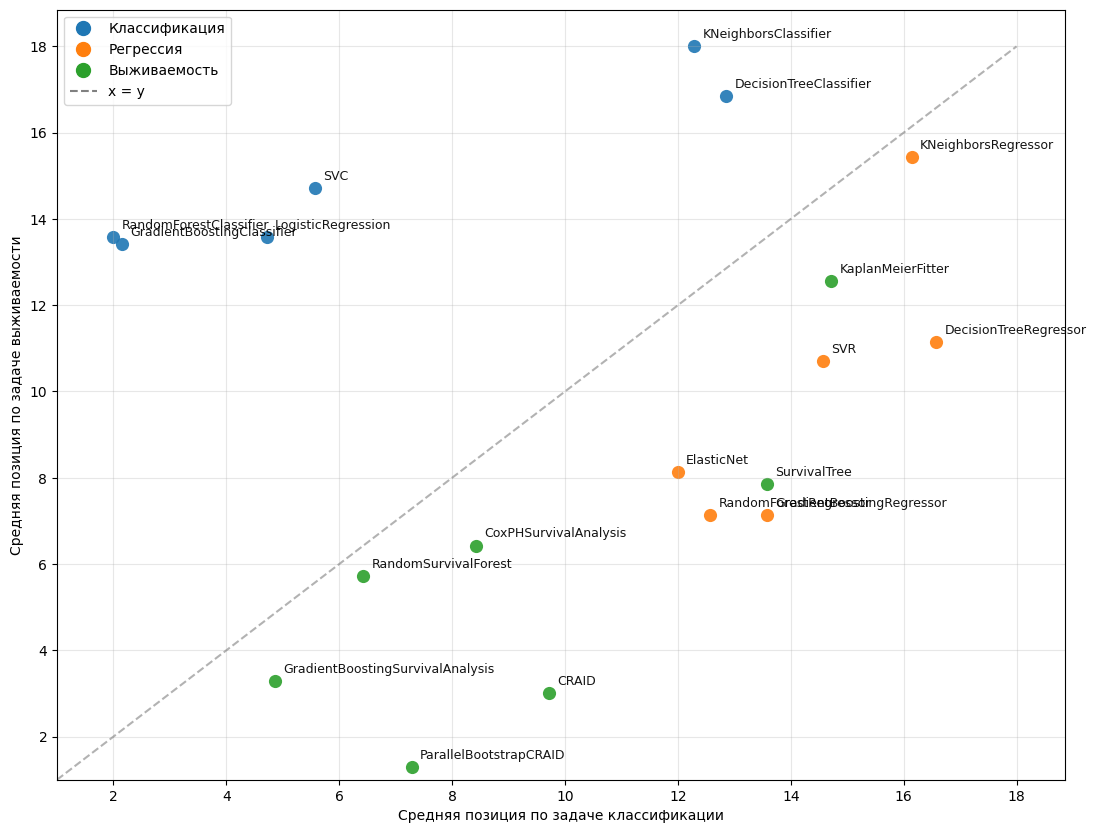

In [2]:
cmp_cs, rank_cs = render_task_comparison("CLASSIFICATION", "SURVIVAL")


,Method,SURVIVAL_Avg_Position,REGRESSION_Avg_Position,group,family_name,family_label,base_model,base_model_short,times,plot_label,delta,abs_delta
0,ParallelBootstrapCRAID,1.285714,4.000000,survival,,Выживаемость,ParallelBootstrapCRAID,PB-CRAID,None,ParallelBootstrapCRAID,-2.714286,2.714286
1,CRAID,3.000000,6.142857,survival,,Выживаемость,CRAID,CRAID,None,CRAID,-3.142857,3.142857
2,GradientBoostingSurvivalAnalysis,3.285714,12.428571,survival,,Выживаемость,GradientBoostingSurvivalAnalysis,GBSA,None,GradientBoostingSurvivalAnalysis,-9.142857,9.142857
3,RandomSurvivalForest,5.714286,16.714286,survival,,Выживаемость,RandomSurvivalForest,RSF,None,RandomSurvivalForest,-11.000000,11.000000
4,CoxPHSurvivalAnalysis,6.428571,13.000000,survival,,Выживаемость,CoxPHSurvivalAnalysis,CoxPH,None,CoxPHSurvivalAnalysis,-6.571429,6.571429
5,RandomForestRegressor,7.142857,1.714286,regression,,Регрессия,RandomForestRegressor,RF-R,None,RandomForestRegressor,5.428571,5.428571
6,GradientBoostingRegressor,7.142857,2.714286,regression,,Регрессия,GradientBoostingRegressor,GB-R,None,GradientBoostingRegressor,4.428571,4.428571
7,SurvivalTree,7.857143,17.857143,survival,,Выживаемость,SurvivalTree,ST,None,SurvivalTree,-10.000000,10.000000
8,ElasticNet,8.142857,3.714286,regression,,Регрессия,ElasticNet,ElasticNet,None,ElasticNet,4.428571,4.428571
9,SVR,10.714286,6.000000,regression,,Регрессия,SVR,SVR,None,SVR,4.714286,4.714286


,Method,plot_label,family_label,base_model,times,SURVIVAL_Avg_Position,REGRESSION_Avg_Position,delta,abs_delta
0,ParallelBootstrapCRAID,ParallelBootstrapCRAID,Выживаемость,ParallelBootstrapCRAID,None,1.285714,4.000000,-2.714286,2.714286
1,CRAID,CRAID,Выживаемость,CRAID,None,3.000000,6.142857,-3.142857,3.142857
2,GradientBoostingSurvivalAnalysis,GradientBoostingSurvivalAnalysis,Выживаемость,GradientBoostingSurvivalAnalysis,None,3.285714,12.428571,-9.142857,9.142857
3,RandomSurvivalForest,RandomSurvivalForest,Выживаемость,RandomSurvivalForest,None,5.714286,16.714286,-11.000000,11.000000
4,CoxPHSurvivalAnalysis,CoxPHSurvivalAnalysis,Выживаемость,CoxPHSurvivalAnalysis,None,6.428571,13.000000,-6.571429,6.571429
5,RandomForestRegressor,RandomForestRegressor,Регрессия,RandomForestRegressor,None,7.142857,1.714286,5.428571,5.428571
6,GradientBoostingRegressor,GradientBoostingRegressor,Регрессия,GradientBoostingRegressor,None,7.142857,2.714286,4.428571,4.428571
7,SurvivalTree,SurvivalTree,Выживаемость,SurvivalTree,None,7.857143,17.857143,-10.000000,10.000000
8,ElasticNet,ElasticNet,Регрессия,ElasticNet,None,8.142857,3.714286,4.428571,4.428571
9,SVR,SVR,Регрессия,SVR,None,10.714286,6.000000,4.714286,4.714286


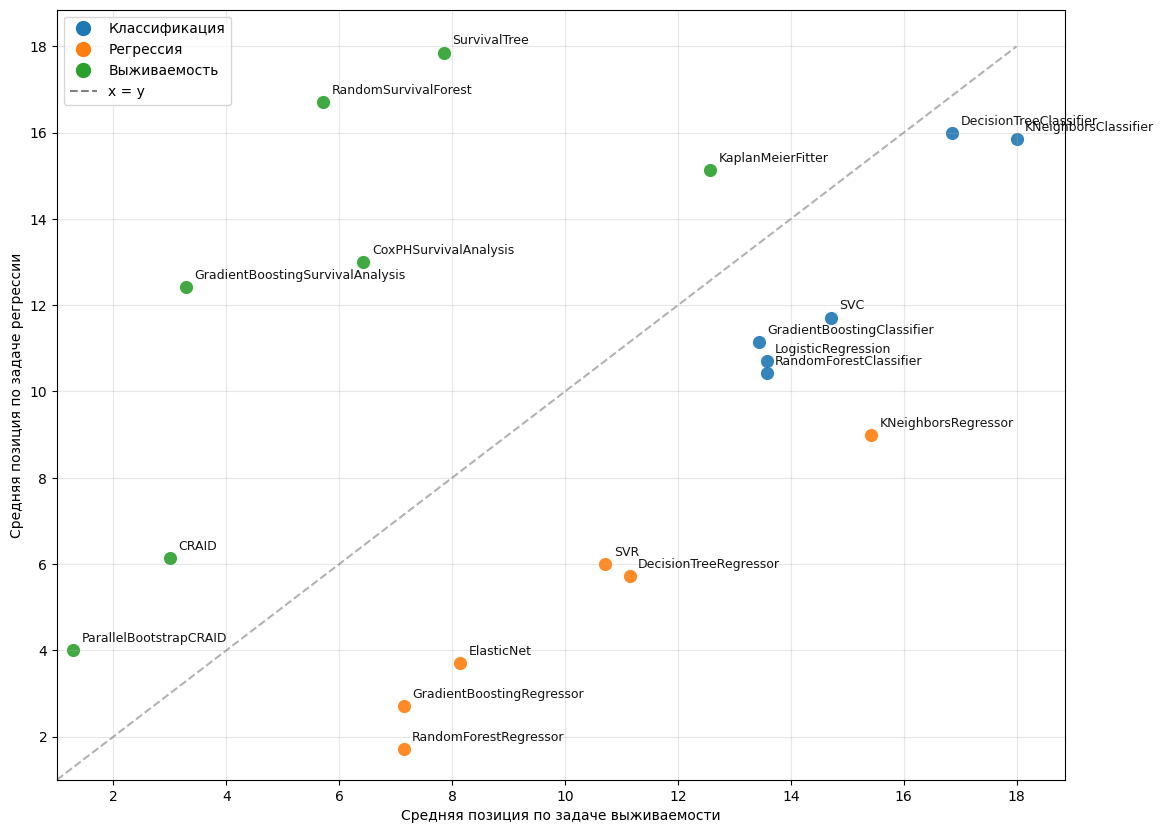

In [3]:
cmp_sr, rank_sr = render_task_comparison("SURVIVAL", "REGRESSION")


,Method,REGRESSION_Avg_Position,CLASSIFICATION_Avg_Position,group,family_name,family_label,base_model,base_model_short,times,plot_label,delta,abs_delta
0,RandomForestRegressor,1.714286,12.571429,regression,,Регрессия,RandomForestRegressor,RF-R,None,RandomForestRegressor,-10.857143,10.857143
1,GradientBoostingRegressor,2.714286,13.571429,regression,,Регрессия,GradientBoostingRegressor,GB-R,None,GradientBoostingRegressor,-10.857143,10.857143
2,ElasticNet,3.714286,12.000000,regression,,Регрессия,ElasticNet,ElasticNet,None,ElasticNet,-8.285714,8.285714
3,ParallelBootstrapCRAID,4.000000,7.285714,survival,,Выживаемость,ParallelBootstrapCRAID,PB-CRAID,None,ParallelBootstrapCRAID,-3.285714,3.285714
4,DecisionTreeRegressor,5.714286,16.571429,regression,,Регрессия,DecisionTreeRegressor,DT-R,None,DecisionTreeRegressor,-10.857143,10.857143
5,SVR,6.000000,14.571429,regression,,Регрессия,SVR,SVR,None,SVR,-8.571429,8.571429
6,CRAID,6.142857,9.714286,survival,,Выживаемость,CRAID,CRAID,None,CRAID,-3.571429,3.571429
7,KNeighborsRegressor,9.000000,16.142857,regression,,Регрессия,KNeighborsRegressor,KNN-R,None,KNeighborsRegressor,-7.142857,7.142857
8,RandomForestClassifier,10.428571,2.000000,classification,,Классификация,RandomForestClassifier,RF,None,RandomForestClassifier,8.428571,8.428571
9,LogisticRegression,10.714286,4.714286,classification,,Классификация,LogisticRegression,LR,None,LogisticRegression,6.000000,6.000000


,Method,plot_label,family_label,base_model,times,REGRESSION_Avg_Position,CLASSIFICATION_Avg_Position,delta,abs_delta
0,RandomForestRegressor,RandomForestRegressor,Регрессия,RandomForestRegressor,None,1.714286,12.571429,-10.857143,10.857143
1,GradientBoostingRegressor,GradientBoostingRegressor,Регрессия,GradientBoostingRegressor,None,2.714286,13.571429,-10.857143,10.857143
2,ElasticNet,ElasticNet,Регрессия,ElasticNet,None,3.714286,12.000000,-8.285714,8.285714
3,ParallelBootstrapCRAID,ParallelBootstrapCRAID,Выживаемость,ParallelBootstrapCRAID,None,4.000000,7.285714,-3.285714,3.285714
4,DecisionTreeRegressor,DecisionTreeRegressor,Регрессия,DecisionTreeRegressor,None,5.714286,16.571429,-10.857143,10.857143
5,SVR,SVR,Регрессия,SVR,None,6.000000,14.571429,-8.571429,8.571429
6,CRAID,CRAID,Выживаемость,CRAID,None,6.142857,9.714286,-3.571429,3.571429
7,KNeighborsRegressor,KNeighborsRegressor,Регрессия,KNeighborsRegressor,None,9.000000,16.142857,-7.142857,7.142857
8,RandomForestClassifier,RandomForestClassifier,Классификация,RandomForestClassifier,None,10.428571,2.000000,8.428571,8.428571
9,LogisticRegression,LogisticRegression,Классификация,LogisticRegression,None,10.714286,4.714286,6.000000,6.000000


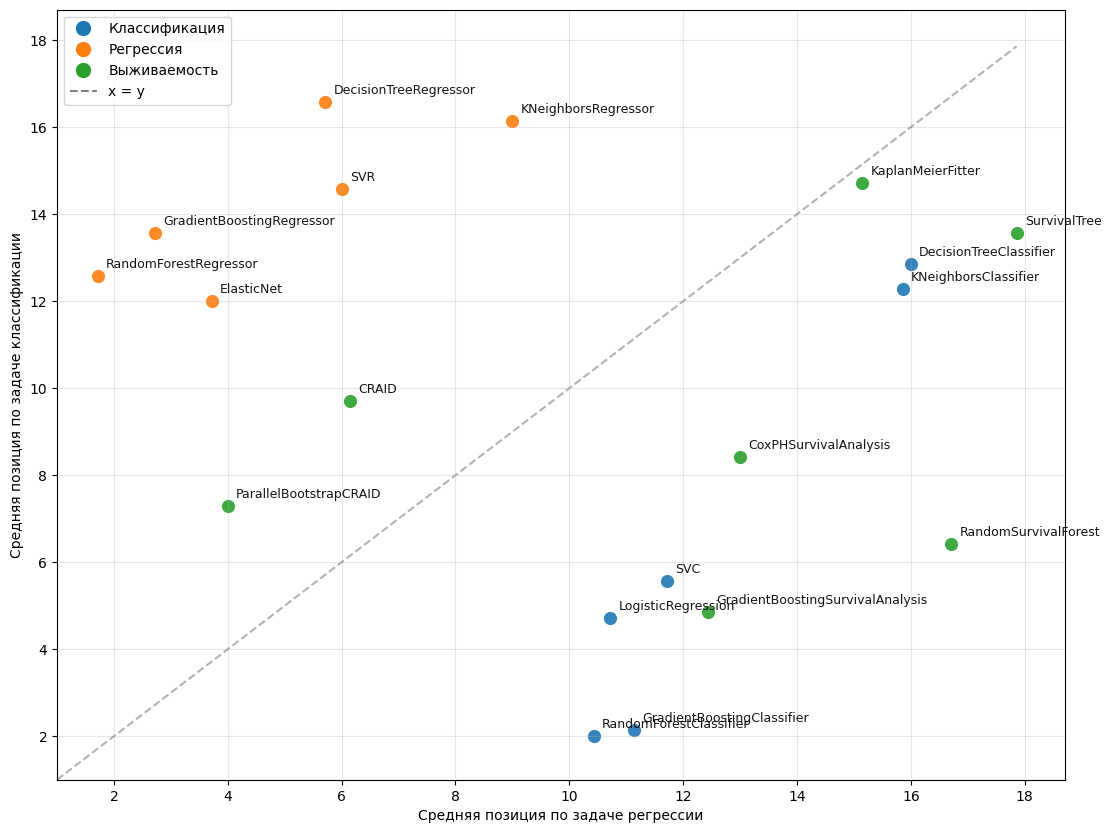

In [4]:
cmp_rc, rank_rc = render_task_comparison("REGRESSION", "CLASSIFICATION")
